In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
def plot_tpr_log(log_path):
    pattern = re.compile(
        r"Round\s+(\d+)\s+–\s+LOCAL TPR pre-agg per client:\s+\[([^\]]+)\]"
    )
    
    records = []
    with open(log_path, 'r', encoding='utf-8') as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rnd = int(m.group(1))
                vals = [float(v.strip().strip("'")) for v in m.group(2).split(',')]
                rec = {'round': rnd}
                for i, tpr in enumerate(vals):
                    rec[f'client_{i}'] = tpr
                records.append(rec)
    
    df = pd.DataFrame(records)
    df = df.sort_values('round').set_index('round')
    
    plt.figure(figsize=(10,6))
    for col in df.columns:
        plt.plot(df.index, df[col], label=col)
    plt.xlabel('Ronda')
    plt.ylabel('TPR')
    plt.title('TPR per Client Evolution')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    return df

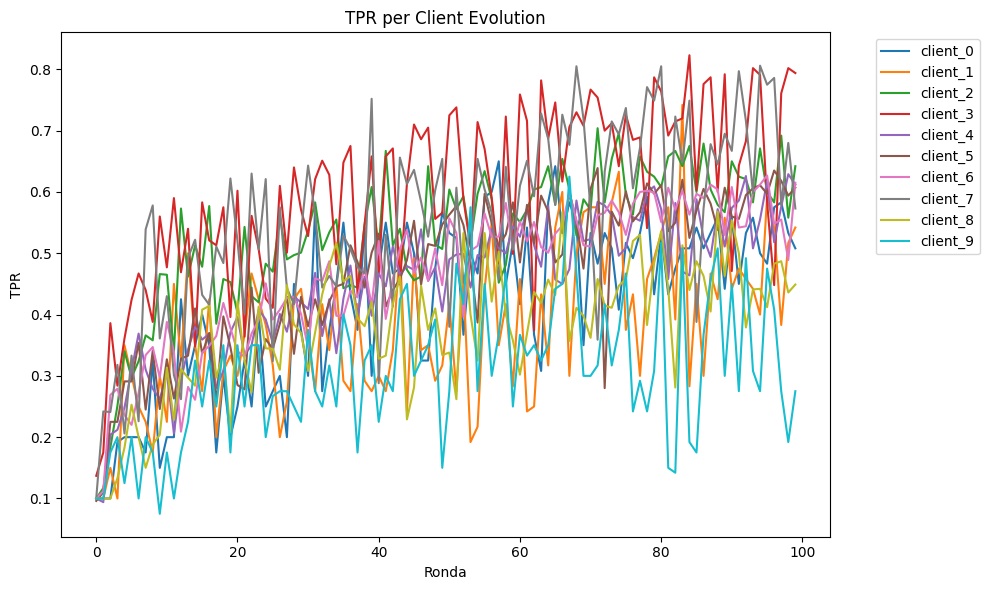

In [3]:
df_tpr = plot_tpr_log('run/run_dapperfl_TPR_0.8.out')

In [2]:
def plot_tpr_mean(log_path, noise_var):
    pattern = re.compile(r"Round\s+(\d+).*?\[([^\]]+)\]")
    rows = []
    with open(log_path) as f:
        for l in f:
            m = pattern.search(l)
            if m:
                rnd = int(m.group(1))
                vals = list(map(lambda v: float(v.strip("' ")), m.group(2).split(',')))
                rows.append([rnd] + vals)
    cols = ['round'] + [f'c{i}' for i in range(len(rows[0]) - 1)]
    df = pd.DataFrame(rows, columns=cols).set_index('round')
    
    ruidosos = [8, 9]
    limpios   = [i for i in df.columns if i not in [f'c{j}' for j in ruidosos]]
    df_ruido   = df[[f'c{j}' for j in ruidosos]]
    df_limpio  = df[limpios]
    
    mean_r = df_ruido.mean(axis=1)
    std_r  = df_ruido.std(axis=1)
    mean_l = df_limpio.mean(axis=1)
    std_l  = df_limpio.std(axis=1)
    
    plt.fill_between(mean_r.index, mean_r-std_r, mean_r+std_r, alpha=0.3)
    plt.plot(mean_r.index, mean_r, label=f'Noise {noise_var}')
    plt.fill_between(mean_l.index, mean_l-std_l, mean_l+std_l, alpha=0.3)
    plt.plot(mean_l.index, mean_l, label='Clean')
    plt.xlabel('Round')
    plt.ylabel('Average TPR')
    plt.legend()
    plt.title(f'Average TPR ± 1σ: Noise {noise_var} vs Clean')
    plt.show()

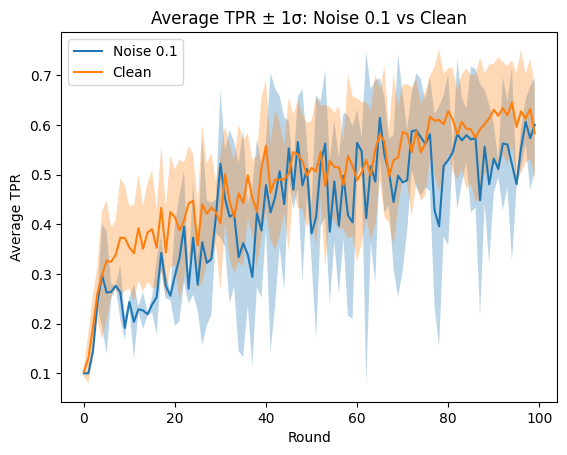

In [4]:
plot_tpr_mean('run/run_dapperfl_TPR_0.1.out', '0.1')

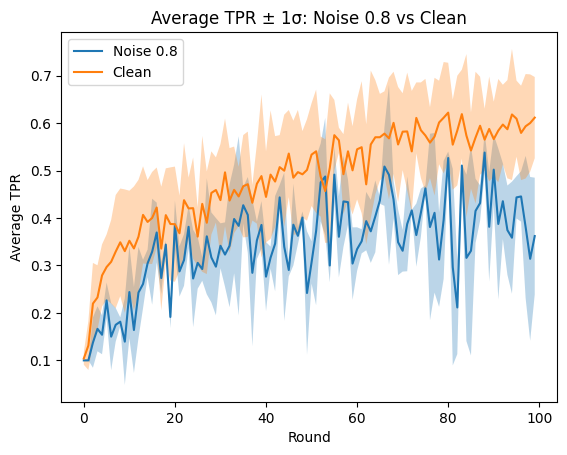

In [10]:
plot_tpr_mean('run/run_dapperfl_TPR_0.8.out', '0.8')

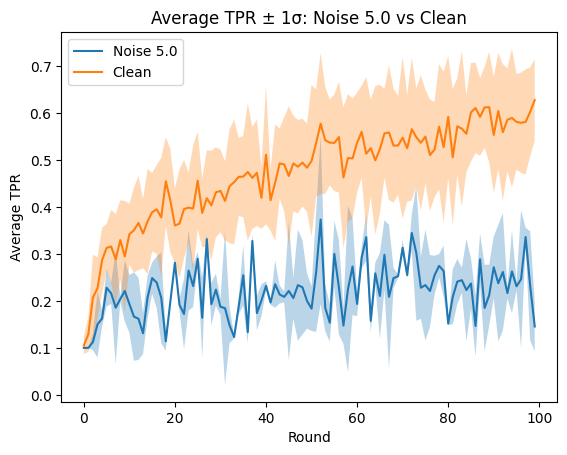

In [11]:
plot_tpr_mean('run/run_dapperfl_TPR_5.out', '5.0')

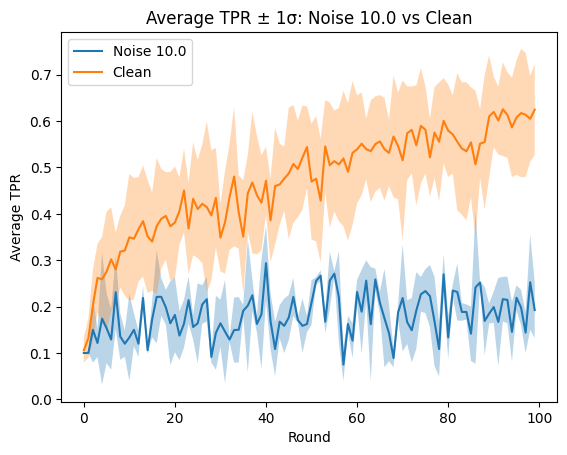

In [7]:
plot_tpr_mean('run/run_dapperfl_TPR_10.out', '10.0')

In [5]:
def plot_tpr_bars(log_path, noise_var):
    pattern = re.compile(
        r"Round\s+(\d+)\s+– LOCAL TPR pre-agg per client: \[([^\]]+)\]"
    )
    best_round = -1
    best_vals = None
    
    with open(log_path) as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rnd = int(m.group(1))
                if rnd > best_round:
                    best_round = rnd
                    best_vals = list(map(float, m.group(2).replace("'", "").split(',')))
    
    df = pd.DataFrame({
        'client': [f'c{i}' for i in range(len(best_vals))],
        'TPR': best_vals
    })
    
    highlight = {'c8', 'c9'}
    colors = ['darkorange' if c in highlight else 'turquoise' for c in df['client']]
    
    plt.figure(figsize=(8,4))
    bars = plt.bar(df['client'], df['TPR'], color=colors, edgecolor='k')
    plt.ylim(0,1)
    plt.ylabel('True Positive Rate')
    plt.xlabel('Client')
    plt.title(f'TPR of each client in round {best_round} — Noise {noise_var}')
    
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2f}", 
                 ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

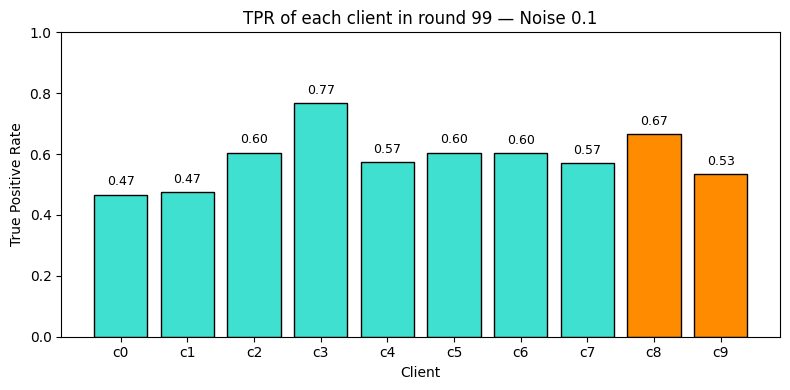

In [6]:
plot_tpr_bars('run/run_dapperfl_TPR_0.1.out', '0.1')

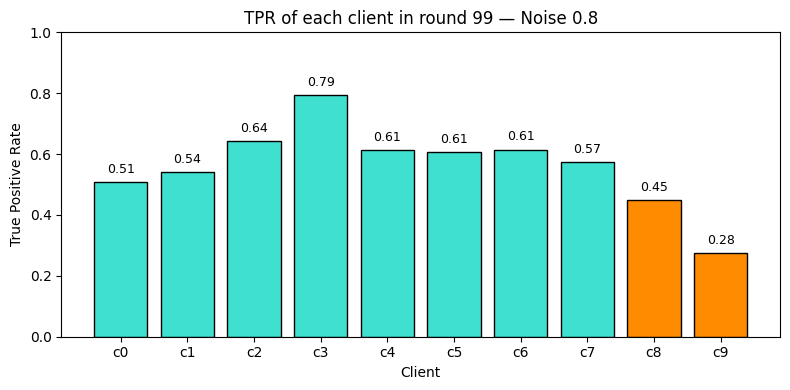

In [11]:
plot_tpr_bars('run/run_dapperfl_TPR_0.8.out', '0.8')

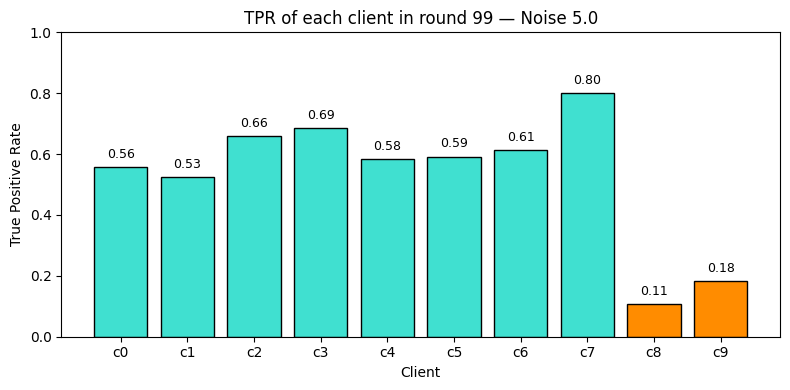

In [12]:
plot_tpr_bars('run/run_dapperfl_TPR_5.out', '5.0')

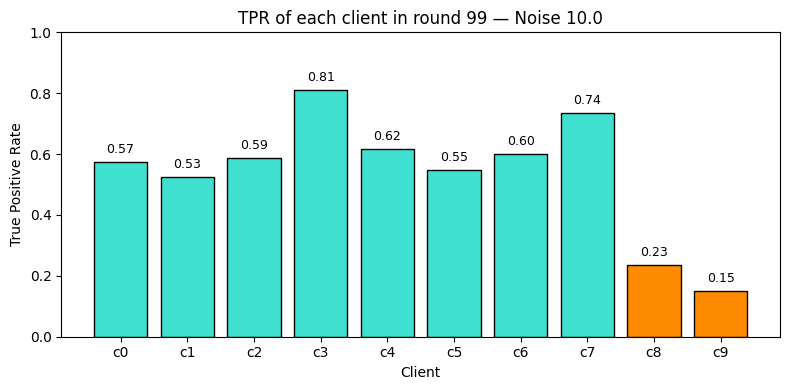

In [13]:
plot_tpr_bars('run/run_dapperfl_TPR_10.out', '10.0')